In [1]:
# Imports
import pickle
import numpy as np
import matplotlib.pyplot as plt

# Load the dataset
with open('data/RML2016.10a_dict.pkl', 'rb') as f:
    data = pickle.load(f, encoding='latin1')

# Check what we got
print(f"Type: {type(data)}")
print(f"Number of keys: {len(data.keys())}")
print(f"\nFirst 5 keys:")
for i, key in enumerate(list(data.keys())[:5]):
    print(f"  {key} -> shape: {data[key].shape}")

Type: <class 'dict'>
Number of keys: 220

First 5 keys:
  ('QPSK', 2) -> shape: (1000, 2, 128)
  ('PAM4', 8) -> shape: (1000, 2, 128)
  ('AM-DSB', -4) -> shape: (1000, 2, 128)
  ('GFSK', 6) -> shape: (1000, 2, 128)
  ('QAM64', 8) -> shape: (1000, 2, 128)


In [2]:
# Get all modulation types and SNR values
mods = sorted(list(set([key[0] for key in data.keys()])))
snrs = sorted(list(set([key[1] for key in data.keys()])))

print(f"Modulation types ({len(mods)}):")
print(mods)
print(f"\nSNR values ({len(snrs)}):")
print(snrs)

Modulation types (11):
['8PSK', 'AM-DSB', 'AM-SSB', 'BPSK', 'CPFSK', 'GFSK', 'PAM4', 'QAM16', 'QAM64', 'QPSK', 'WBFM']

SNR values (20):
[-20, -18, -16, -14, -12, -10, -8, -6, -4, -2, 0, 2, 4, 6, 8, 10, 12, 14, 16, 18]


Sample shape: (2, 128)
I channel (in-phase): [-0.00029786 -0.00082597 -0.00147865 -0.0023948  -0.00346055 -0.00448169
 -0.00543849 -0.00608574 -0.00654883 -0.00671541]...
Q channel (quadrature): [ 6.2848958e-05 -4.4179478e-04 -9.7293709e-04 -1.6640740e-03
 -2.4328057e-03 -3.3180469e-03 -4.4307890e-03 -5.4567698e-03
 -6.4610136e-03 -7.3640840e-03]...


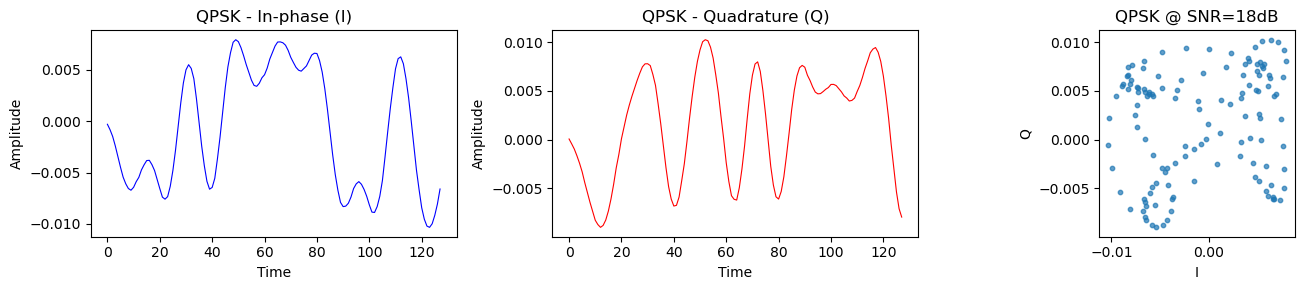

In [3]:
# Pick one sample to look at
mod = 'QPSK'
snr = 18  # high SNR so it's clean
sample = data[(mod, snr)][0]  # first sample

print(f"Sample shape: {sample.shape}")
print(f"I channel (in-phase): {sample[0][:10]}...")  # first 10 values
print(f"Q channel (quadrature): {sample[1][:10]}...")

# Plot it
fig, axes = plt.subplots(1, 3, figsize=(14, 3))

# I component over time
axes[0].plot(sample[0], 'b-', linewidth=0.8)
axes[0].set_xlabel('Time')
axes[0].set_ylabel('Amplitude')
axes[0].set_title(f'{mod} - In-phase (I)')

# Q component over time
axes[1].plot(sample[1], 'r-', linewidth=0.8)
axes[1].set_xlabel('Time')
axes[1].set_ylabel('Amplitude')
axes[1].set_title(f'{mod} - Quadrature (Q)')

# I vs Q scatter (constellation-like)
axes[2].scatter(sample[0], sample[1], s=10, alpha=0.7)
axes[2].set_xlabel('I')
axes[2].set_ylabel('Q')
axes[2].set_title(f'{mod} @ SNR={snr}dB')
axes[2].set_aspect('equal')

plt.tight_layout()
plt.show()

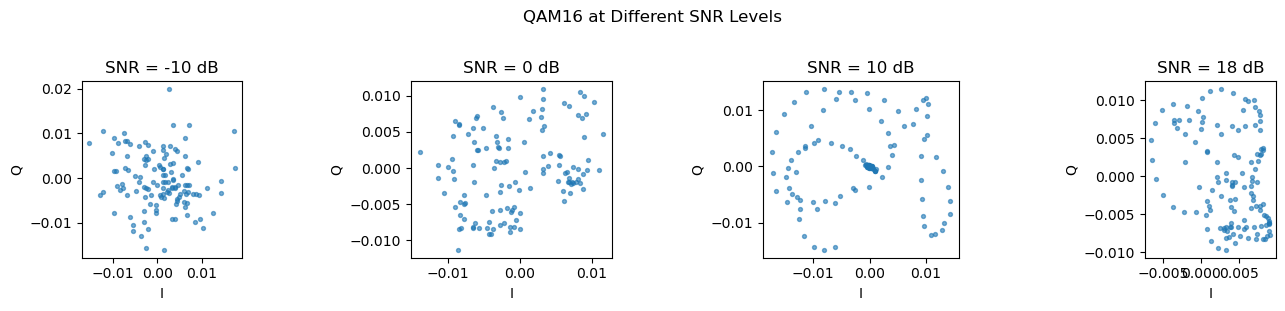

In [4]:
# Compare same modulation at different SNR levels
mod = 'QAM16'
snr_values = [-10, 0, 10, 18]

fig, axes = plt.subplots(1, 4, figsize=(14, 3))

for ax, snr in zip(axes, snr_values):
    sample = data[(mod, snr)][0]
    ax.scatter(sample[0], sample[1], s=8, alpha=0.6)
    ax.set_xlabel('I')
    ax.set_ylabel('Q')
    ax.set_title(f'SNR = {snr} dB')
    ax.set_aspect('equal')

fig.suptitle(f'{mod} at Different SNR Levels', y=1.02)
plt.tight_layout()
plt.savefig('figures/qam16_snr_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

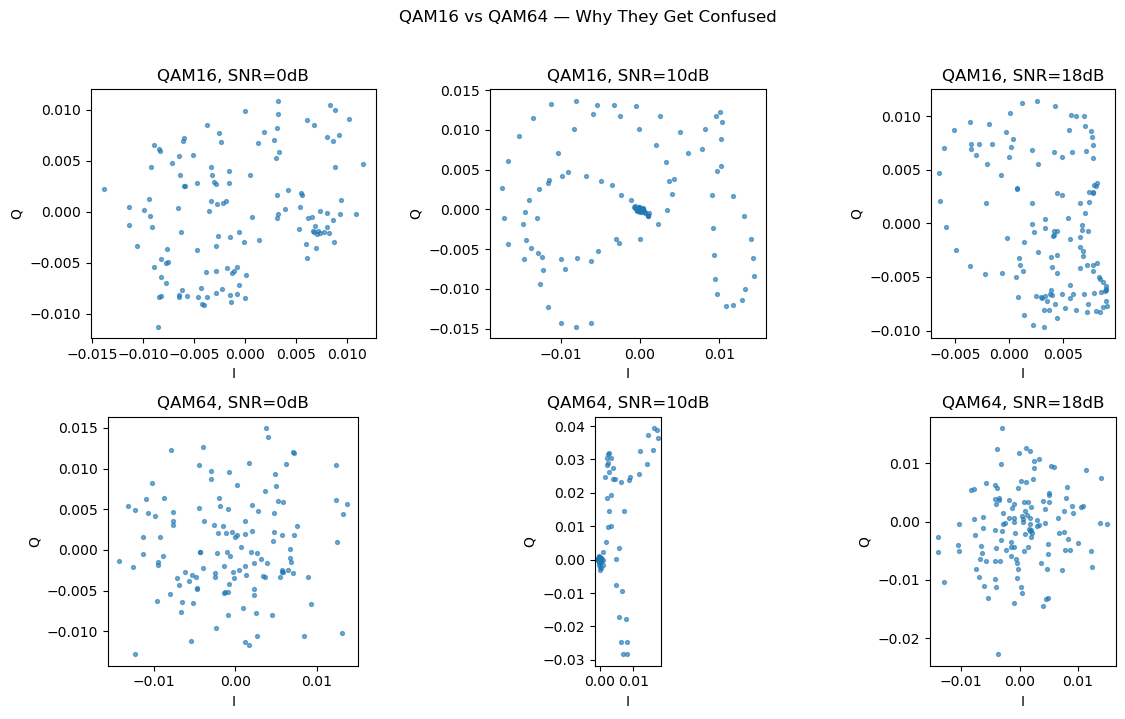

In [5]:
# QAM16 vs QAM64 comparison
fig, axes = plt.subplots(2, 3, figsize=(12, 7))

for row, mod in enumerate(['QAM16', 'QAM64']):
    for col, snr in enumerate([0, 10, 18]):
        sample = data[(mod, snr)][0]
        axes[row, col].scatter(sample[0], sample[1], s=8, alpha=0.6)
        axes[row, col].set_title(f'{mod}, SNR={snr}dB')
        axes[row, col].set_xlabel('I')
        axes[row, col].set_ylabel('Q')
        axes[row, col].set_aspect('equal')

plt.suptitle('QAM16 vs QAM64 — Why They Get Confused', y=1.02)
plt.tight_layout()
plt.savefig('figures/qam_confusion.png', dpi=150, bbox_inches='tight')
plt.show()

In [6]:
# Stack all data into arrays for training
X = []
y = []
snr_labels = []

# Create label mapping
mod_to_label = {mod: i for i, mod in enumerate(mods)}

for (mod, snr), samples in data.items():
    X.append(samples)
    y.extend([mod_to_label[mod]] * len(samples))
    snr_labels.extend([snr] * len(samples))

X = np.vstack(X)
y = np.array(y)
snr_labels = np.array(snr_labels)

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"snr_labels shape: {snr_labels.shape}")
print(f"\nLabel mapping:")
for mod, label in mod_to_label.items():
    print(f"  {label}: {mod}")

X shape: (220000, 2, 128)
y shape: (220000,)
snr_labels shape: (220000,)

Label mapping:
  0: 8PSK
  1: AM-DSB
  2: AM-SSB
  3: BPSK
  4: CPFSK
  5: GFSK
  6: PAM4
  7: QAM16
  8: QAM64
  9: QPSK
  10: WBFM


In [7]:
from sklearn.model_selection import train_test_split

# Split: 80% train, 20% test (stratified to keep class balance)
X_train, X_test, y_train, y_test, snr_train, snr_test = train_test_split(
    X, y, snr_labels, test_size=0.2, random_state=42, stratify=y
)

# Split train into train/val: 90% train, 10% val
X_train, X_val, y_train, y_val, snr_train, snr_val = train_test_split(
    X_train, y_train, snr_train, test_size=0.1, random_state=42, stratify=y_train
)

print(f"Train: {X_train.shape[0]} samples")
print(f"Val:   {X_val.shape[0]} samples")
print(f"Test:  {X_test.shape[0]} samples")

Train: 158400 samples
Val:   17600 samples
Test:  44000 samples


In [8]:
# Save preprocessed data for later use
np.savez('data/processed_data.npz',
         X_train=X_train, X_val=X_val, X_test=X_test,
         y_train=y_train, y_val=y_val, y_test=y_test,
         snr_train=snr_train, snr_val=snr_val, snr_test=snr_test)

# Save label mapping
import json
with open('data/label_mapping.json', 'w') as f:
    json.dump(mod_to_label, f)

print("Saved preprocessed data to data/processed_data.npz")
print("Saved label mapping to data/label_mapping.json")

Saved preprocessed data to data/processed_data.npz
Saved label mapping to data/label_mapping.json


In [9]:
# Summary
print("=" * 50)
print("DATASET SUMMARY")
print("=" * 50)
print(f"Total samples:     {len(X):,}")
print(f"Sample shape:      {X.shape[1:]} (channels × timesteps)")
print(f"Number of classes: {len(mods)}")
print(f"SNR range:         {min(snrs)} to {max(snrs)} dB")
print(f"SNR steps:         {len(snrs)}")
print(f"\nTrain/Val/Test split: {len(X_train):,} / {len(X_val):,} / {len(X_test):,}")
print(f"\nModulation types: {mods}")
print("=" * 50)

DATASET SUMMARY
Total samples:     220,000
Sample shape:      (2, 128) (channels × timesteps)
Number of classes: 11
SNR range:         -20 to 18 dB
SNR steps:         20

Train/Val/Test split: 158,400 / 17,600 / 44,000

Modulation types: ['8PSK', 'AM-DSB', 'AM-SSB', 'BPSK', 'CPFSK', 'GFSK', 'PAM4', 'QAM16', 'QAM64', 'QPSK', 'WBFM']
